Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library.

In [2]:
install.packages("tidymodels")
library(tidymodels)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘listenv’, ‘parallelly’, ‘splitfngr’, ‘prodlim’, ‘future’, ‘warp’, ‘mixopt’, ‘numDeriv’, ‘lbfgs’, ‘RcppArmadillo’, ‘DiceDesign’, ‘sfd’, ‘sparsevctrs’, ‘patchwork’, ‘globals’, ‘clock’, ‘gower’, ‘ipred’, ‘timeDate’, ‘furrr’, ‘slider’, ‘GauPro’, ‘modelenv’, ‘dials’, ‘hardhat’, ‘infer’, ‘modeldata’, ‘parsnip’, ‘recipes’, ‘rsample’, ‘tailor’, ‘tune’, ‘workflows’, ‘workflowsets’, ‘yardstick’


── Attaching packages ────────────────────────────────────── tidymodels 1.5.0 ──

✔ broom        1.0.13     ✔ recipes      1.4.0 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.6.0      ✔ workflows    1.3.0 
✔ parsnip      1.6.1      ✔ workflowsets 1.1.1 
✔ purrr

The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [4]:
url <- "https://raw.githubusercontent.com/TheintTheintSan/a04/main/diabetes.csv"

In [5]:
# diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))
diabetes = readr::read_csv(url) |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [8]:
diabetes_train |> head()

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,85,66,29,0,26.6,0.351,31,0
1,89,66,23,94,28.1,0.167,21,0
5,116,74,0,0,25.6,0.201,30,0
4,110,92,0,0,37.6,0.191,30,0
10,139,80,0,0,27.1,1.441,57,0
1,103,30,38,83,43.3,0.183,33,0


In [15]:

outcome_counts <- table(diabetes$Outcome)
print(outcome_counts)


  0   1 
500 268 


::❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

Outcome variable is suitable for the outcome in a logistic regression model as it is the binary (0,1).

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

| Column name | Description |

| :---------- | :---------- |
| Glucose     | |
| BMI         | |

Glucose: Plasma glucose concentration from an oral glucose tolerance test.   
BMI: Body Mass Index        

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:** I dont think we have balanced data as the 0 outcome has 500 count and 1 outcome has 268 count.

Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`.

In [17]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,89.0
0,BMI,28.1
0,Glucose,116.0
0,BMI,25.6


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`.

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

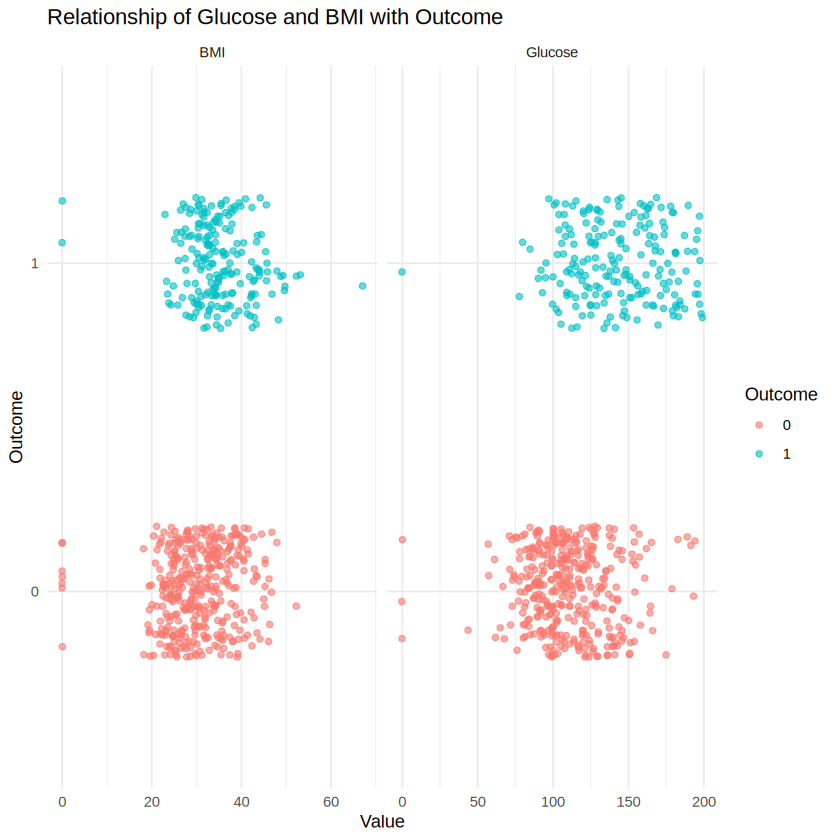

In [26]:
ggplot(plot_df, aes(x = value, y = factor(Outcome), color = factor(Outcome))) +
  geom_jitter(height = 0.2, alpha = 0.6) +
  facet_wrap(~name, ncol = 2
, scales = 'free_x'
) +
  labs(
    x = "Value",
    y = "Outcome",
    color = "Outcome",
    title = "Relationship of Glucose and BMI with Outcome"
  ) +
  theme_minimal()



❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**Without the scales = 'free_x' the glucose and BMI share one x-axis value range from 0-200. But with the scales, they have their own range.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors.
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [40]:
mod_fit <- glm(Outcome ~ BMI + Glucose, data = diabetes_train, family = binomial)
summary(mod_fit)




Call:
glm(formula = Outcome ~ BMI + Glucose, family = binomial, data = diabetes_train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -7.567666   0.700023 -10.811  < 2e-16 ***
BMI          0.067293   0.015278   4.405 1.06e-05 ***
Glucose      0.037777   0.003916   9.646  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 745.11  on 575  degrees of freedom
Residual deviance: 571.33  on 573  degrees of freedom
AIC: 577.33

Number of Fisher Scoring iterations: 4


Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model.

In [43]:
diabetes_test_wPred <- augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |>head()

Outcome,BMI,Glucose,.fitted,.resid,.hat,.sigma,.cooksd,.std.resid
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,26.6,85,-2.5666406,-0.3846746,0.003091869,1.100590,7.963641e-05,-0.3852706
0,28.1,89,-2.3145937,-0.4341070,0.003122912,1.100572,1.034999e-04,-0.4347864
0,25.6,116,-1.4628545,-0.6454352,0.003900437,1.100466,3.034428e-04,-0.6466976
0,37.6,110,-0.8819958,-0.8323357,0.004220326,1.100321,5.872897e-04,-0.8340977
0,27.1,139,-0.4930493,-0.9764290,0.005124985,1.100163,1.054158e-03,-0.9789408
0,43.3,103,-0.7628614,-0.8749432,0.009826407,1.100277,1.557917e-03,-0.8792739


Run the code below to generate a confusion matrix for your model predictions.

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [46]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test) %>%
  mutate(.pred_class = factor(ifelse(.fitted > 0.5, "1", "0"), levels = levels(diabetes_train$Outcome)))

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 352 115
         1  23  86

❓ Based on the confusion matrix above,
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

About 201 individuals have diabetes in the test data.

of those that actually had diabetes, only 86 were predicted to have diabetes by the mode.

About 23 individuals predicted to have diabetes did not have diabetes.

